<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/AdaBoostClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install ucimlrepo

In [47]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

#Predict Students' Dropout and Academic Success

In [48]:
X.sample(5)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1037,1,1,1,9238,1,1,154.0,1,1,3,...,0,0,6,6,6,13.166667,0,10.8,1.4,1.74
516,2,39,1,9003,1,1,120.0,1,37,19,...,0,0,6,15,5,12.400000,0,8.9,1.4,3.51
79,2,39,1,8014,0,1,120.0,1,37,37,...,0,0,6,6,6,11.666667,0,10.8,1.4,1.74
18,1,1,1,9130,1,1,137.0,1,3,19,...,1,0,5,8,4,12.250000,2,10.8,1.4,1.74
380,4,39,1,9500,1,19,133.1,1,38,19,...,0,0,8,12,6,10.978571,0,16.2,0.3,-0.92


In [49]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [50]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  4424 non-null   object
dtypes: object(1)
memory usage: 34.7+ KB


In [51]:
X.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [52]:
X.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

<Axes: xlabel='Course', ylabel='Gender'>

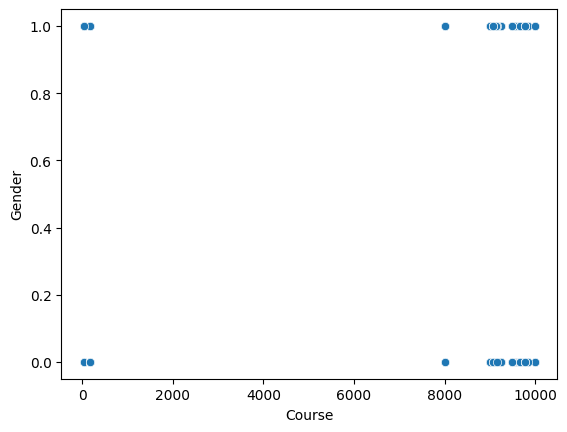

In [54]:
sns.scatterplot(X,x='Course',y='Gender')

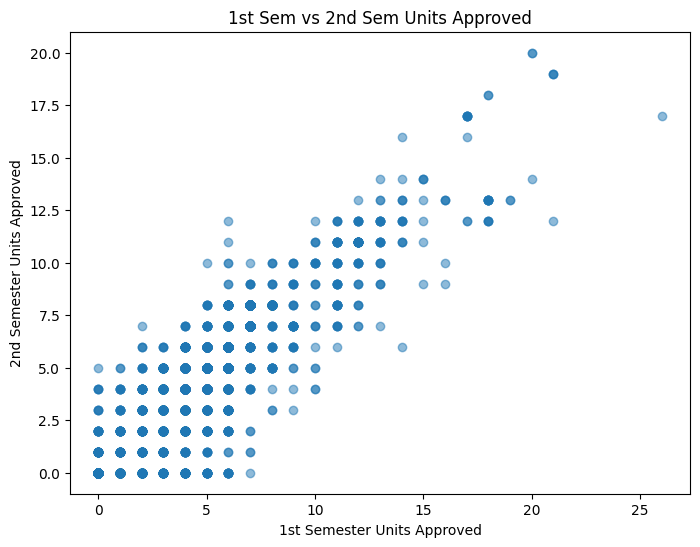

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X['Curricular units 1st sem (approved)'],
    X['Curricular units 2nd sem (approved)'],
    alpha=0.5
)

plt.xlabel('1st Semester Units Approved')
plt.ylabel('2nd Semester Units Approved')
plt.title('1st Sem vs 2nd Sem Units Approved')

plt.show()

<Axes: xlabel='Curricular units 1st sem (approved)', ylabel='Curricular units 2nd sem (approved)'>

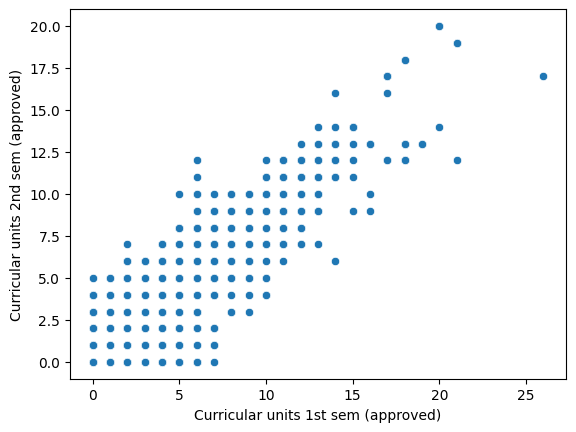

In [56]:
sns.scatterplot(X,x='Curricular units 1st sem (approved)',y='Curricular units 2nd sem (approved)')

In [57]:
y.sample(5)

,Target
2059,Dropout
4245,Dropout
2336,Dropout
3645,Graduate
3761,Dropout


In [58]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [59]:
y=pd.DataFrame(y)


In [60]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       4424 non-null   int64
dtypes: int64(1)
memory usage: 34.7 KB


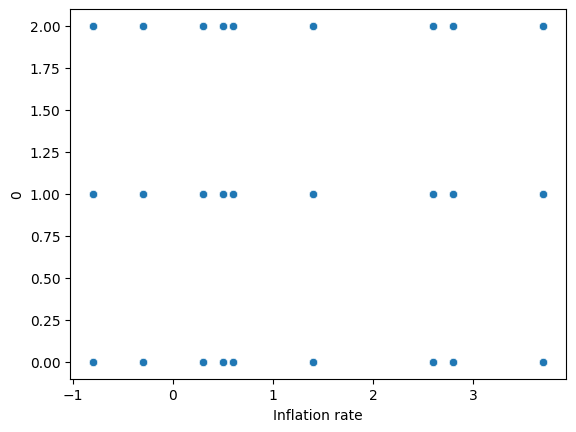

In [61]:
y = y.iloc[:, 0]

sns.scatterplot(x=X['Inflation rate'], y=y)
plt.show()

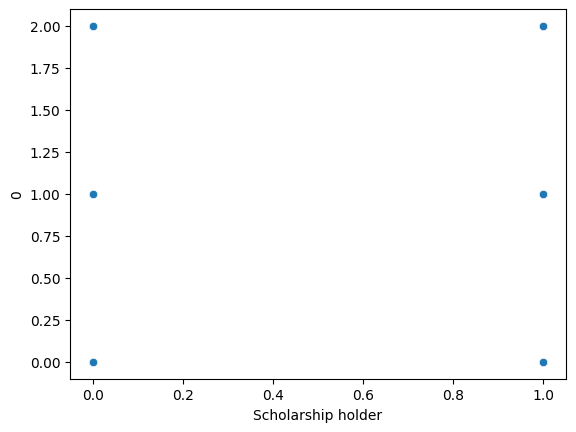

In [62]:
sns.scatterplot(x=X['Scholarship holder'], y=y)
plt.show()

<Axes: ylabel='Density'>

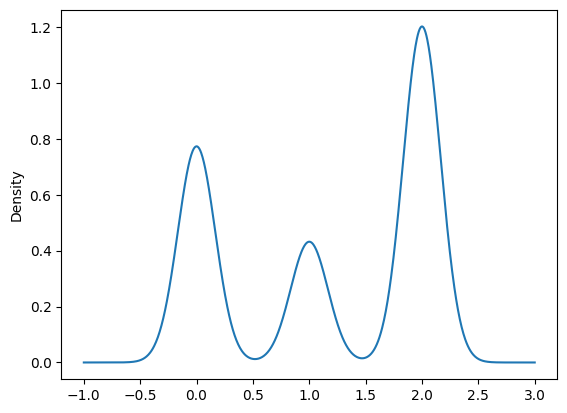

In [63]:
y.plot(kind='kde')

In [64]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [65]:
from sklearn.preprocessing import StandardScaler


In [67]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [68]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [69]:
x_train=pd.DataFrame(x_train)
x_test=pd.DataFrame(x_test)

In [70]:
x_train.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
1080,-0.294763,1.161571,-0.557496,0.551005,-2.789559,-0.343865,2.066063,5.835352,1.132802,-0.217625,...,-0.194476,-0.282375,-0.540122,0.500371,-0.143524,0.052256,-0.196156,1.475143,1.133876,-1.790138
1943,-0.294763,1.390952,-0.557496,0.148321,0.358480,-0.343865,-0.426755,3.451104,-1.179038,-1.131312,...,-0.194476,-0.282375,-0.540122,-0.764134,-1.484596,-1.962344,-0.196156,1.475143,1.133876,-1.790138
779,-0.294763,-1.017551,-0.557496,0.111583,0.358480,-0.343865,0.479724,-0.125267,-1.179038,-0.217625,...,-0.194476,-0.282375,-0.082937,-0.258332,0.527012,0.372034,1.157054,1.737437,-0.678879,-0.408681
486,-0.294763,-0.100026,-0.557496,0.118740,0.358480,-0.343865,-0.955534,-0.125267,-1.114820,-1.261839,...,2.753064,-0.282375,-0.540122,0.753272,-0.143524,0.244123,1.157054,-0.810554,-1.476492,-1.376581
1608,-0.294763,-1.017551,1.719018,-4.134254,0.358480,-0.343865,-0.426755,-0.125267,-1.179038,-1.392365,...,-0.194476,-0.282375,-2.826047,-2.028640,-1.484596,-1.962344,-0.196156,-0.810554,-1.476492,-1.376581


In [71]:
ada=AdaBoostClassifier()
ada.fit(x_train,y_train)

AdaBoostClassifier()

In [72]:
y_pred=ada.predict(x_test)
accuracy_score(y_test,y_pred)

0.7310734463276836

In [73]:
dclf=DecisionTreeClassifier()
dclf.fit(x_train,y_train)

DecisionTreeClassifier()

In [74]:
y_pred=dclf.predict(x_test)
accuracy_score(y_test,y_pred)

0.6711864406779661

In [75]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [76]:
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.7661016949152543

In [78]:
ada2=AdaBoostClassifier(n_estimators=100)
ada2.fit(x_train,y_train)

AdaBoostClassifier(n_estimators=100)

In [79]:
y_pred=ada2.predict(x_test)
accuracy_score(y_test,y_pred)

0.7491525423728813

# AdaBoost Classifier — Revision Notes

## 1. What is AdaBoost?

**AdaBoost (Adaptive Boosting)** is an **ensemble learning algorithm** that combines multiple weak classifiers to create a strong classifier.

The most common weak learner is a **Decision Tree with limited depth**, usually called a **Decision Stump**.

> **Key idea:** AdaBoost focuses more on the samples that were incorrectly classified by previous weak learners.

### In simple words

```text
Weak Model 1
     ↓
Find wrong predictions
     ↓
Give wrong samples more importance
     ↓
Weak Model 2
     ↓
Again focus on mistakes
     ↓
Weak Model 3
     ↓
Combine all weak models
     ↓
Strong Classifier
```

---

# 2. Why is AdaBoost used?

A single weak classifier may have poor performance.

AdaBoost combines several weak classifiers sequentially so that their combined prediction becomes much stronger.

### Example

Suppose we have 10 training samples.

The first decision stump makes 3 mistakes.

AdaBoost increases the importance of those 3 incorrectly classified samples.

The next classifier therefore pays more attention to those difficult samples.

This process continues for multiple iterations.

---

# 3. How AdaBoost Works

AdaBoost works **sequentially**.

Unlike Random Forest, the trees are not built independently.

### Step 1 — Initialize sample weights

Initially, every training sample gets equal weight.

For `n` samples:

[
w_i = \frac{1}{n}
]

Example:

```text
5 samples

Sample     Weight
A          0.20
B          0.20
C          0.20
D          0.20
E          0.20
```

---

## Step 2 — Train a weak learner

Train a weak classifier, commonly:

```text
Decision Tree
max_depth = 1
```

This is called a **Decision Stump**.

---

## Step 3 — Calculate error

Find the weighted error of the weak learner.

[
error = \sum w_i
]

for incorrectly classified samples.

More precisely:

[
\epsilon_t =
\sum_{i=1}^{n} w_i I(y_i \neq h_t(x_i))
]

where:

* `ε` = weighted error
* `wᵢ` = weight of sample `i`
* `hₜ(x)` = prediction of weak learner
* `I` = indicator function

---

## Step 4 — Calculate learner weight

AdaBoost gives a weight to the weak classifier based on its error.

For binary AdaBoost:

[
\alpha_t =
\frac{1}{2}
\ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)
]

### Interpretation

| Error       | Learner Weight  |
| ----------- | --------------- |
| Low error   | High weight     |
| High error  | Low weight      |
| Error ≈ 0.5 | Weight ≈ 0      |
| Error > 0.5 | Negative weight |

Therefore:

> **Better weak learners get more importance in the final prediction.**

---

# 4. Update Sample Weights

Now AdaBoost increases the weight of incorrectly classified samples.

Correctly classified samples receive less importance.

Conceptually:

```text
Correct prediction
        ↓
Decrease weight

Wrong prediction
        ↓
Increase weight
```

The weights are then normalized so that their sum becomes 1.

---

# 5. Repeat the Process

The process is repeated for a specified number of estimators.

```text
Dataset
   ↓
Weak Learner 1
   ↓
Increase weight of mistakes
   ↓
Weak Learner 2
   ↓
Increase weight of mistakes
   ↓
Weak Learner 3
   ↓
...
   ↓
Final Ensemble
```

---

# 6. Final Prediction

All weak classifiers vote, but their votes are **weighted** according to their learner weights.

For binary classification:

[
H(x) =
sign\left(
\sum_{t=1}^{T}\alpha_t h_t(x)
\right)
]

where:

* `T` = number of weak learners
* `αₜ` = weight of learner
* `hₜ(x)` = prediction of learner

### Important

The final model is **not simply majority voting**.

It is **weighted voting**.

---

# 7. Simple Example

Suppose AdaBoost creates 3 weak classifiers.

| Model   | Prediction | Weight |
| ------- | ---------- | -----: |
| Model 1 | Class A    |    0.8 |
| Model 2 | Class B    |    0.4 |
| Model 3 | Class A    |    0.9 |

Weighted votes:

```text
Class A = 0.8 + 0.9 = 1.7

Class B = 0.4
```

Therefore:

```text
Final prediction = Class A
```

---

# 8. Main Characteristics

### AdaBoost is:

* An **ensemble learning algorithm**
* A **boosting algorithm**
* Usually a **sequential algorithm**
* Mainly used for **classification**
* Can also be adapted for regression (`AdaBoostRegressor`)
* Commonly uses **Decision Stumps**
* Focuses on **misclassified observations**
* Uses **weighted voting**
* Reduces bias by combining weak learners

---

# 9. Where is AdaBoost Applicable?

AdaBoost is applicable when the target variable is **categorical**.

### Good use cases

* Binary classification
* Multiclass classification
* Customer churn prediction
* Spam detection
* Fraud detection
* Medical classification
* Customer response prediction
* Credit risk classification
* Image/object classification

### Example

```text
Input Features
      ↓
Age
Income
Credit Score
Loan Amount
      ↓
AdaBoost Classifier
      ↓
Loan Approved / Rejected
```

---

# 10. When Should You Use AdaBoost?

AdaBoost can be a good choice when:

* Your dataset has **structured/tabular data**
* A simple model is underfitting
* You want to combine several weak learners
* You need a powerful classification model
* Your dataset does not contain too many extreme outliers/noisy samples

---

# 11. When Should You Avoid AdaBoost?

AdaBoost can be sensitive to:

### 1. Noise

Because AdaBoost focuses heavily on incorrectly classified samples, noisy observations can receive very high weights.

```text
Noisy sample
     ↓
Repeatedly misclassified
     ↓
Weight keeps increasing
     ↓
Model focuses too much on noise
```

### 2. Outliers

Outliers can also become highly influential.

### 3. Very noisy datasets

In highly noisy datasets, other algorithms such as Random Forest or Gradient Boosting may sometimes be more robust.

---

# 12. Important Hyperparameters

In Scikit-learn:

```python
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier()
```

Important hyperparameters are:

---

## `n_estimators`

Number of weak learners.

```python
AdaBoostClassifier(n_estimators=50)
```

Default is commonly:

```text
50
```

### Effect

Higher `n_estimators`:

* More weak learners
* Can improve performance
* Increases training time
* May increase overfitting in some situations

Typical values:

```text
50
100
200
```

---

# 13. `learning_rate`

Controls the contribution of each weak learner.

```python
AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1
)
```

### Relationship

There is usually a trade-off between:

```text
learning_rate ↓
       +
n_estimators ↑
```

For example:

```text
learning_rate = 0.1
n_estimators = 200
```

may produce a similar level of model complexity to a larger learning rate with fewer estimators, though the results are not necessarily identical.

### Common values

```text
0.01
0.05
0.1
0.5
1.0
```

---

# 14. `estimator`

Specifies the weak learner.

Example:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base_model = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100
)
```

The default weak learner in modern scikit-learn is a shallow decision tree.

---

# 15. `algorithm`

In older scikit-learn versions, you may see:

```python
algorithm='SAMME'
```

or:

```python
algorithm='SAMME.R'
```

However, **check the scikit-learn version you are using**, because this parameter has changed across versions.

For current code, it is better not to blindly copy older tutorials.

---

# 16. Important Hyperparameters — Quick Revision

| Hyperparameter  | Meaning                      | Typical values |
| --------------- | ---------------------------- | -------------- |
| `n_estimators`  | Number of weak learners      | 50, 100, 200   |
| `learning_rate` | Contribution of each learner | 0.01–1         |
| `estimator`     | Base/weak learner            | Decision Tree  |
| `random_state`  | Reproducibility              | 42             |

### Most important

For interviews and practical ML:

```text
n_estimators
learning_rate
estimator
```

---

# 17. AdaBoost vs Random Forest

| Feature            | AdaBoost              | Random Forest            |
| ------------------ | --------------------- | ------------------------ |
| Type               | Boosting              | Bagging                  |
| Training           | Sequential            | Parallel/independent     |
| Main idea          | Focus on mistakes     | Randomize trees/features |
| Base learners      | Usually shallow trees | Usually deeper trees     |
| Sensitive to noise | More sensitive        | Generally more robust    |
| Main goal          | Reduce bias           | Reduce variance          |
| Voting             | Weighted              | Majority voting          |
| Feature randomness | Not the main idea     | Important                |

### Easy memory trick

```text
AdaBoost → Fix mistakes

Random Forest → Build many random trees
```

---

# 18. AdaBoost vs Gradient Boosting

Both are **boosting algorithms**, but their mechanisms are different.

| AdaBoost                         | Gradient Boosting                               |
| -------------------------------- | ----------------------------------------------- |
| Focuses on misclassified samples | Focuses on residual/errors                      |
| Updates sample weights           | Fits next model to errors/residuals             |
| Weighted weak learners           | Additive model                                  |
| Often uses shallow trees         | Usually uses decision trees                     |
| Sensitive to noisy observations  | Also can overfit but has different optimization |

---

# 19. Advantages

### Advantages of AdaBoost

1. Simple concept
2. Easy to implement
3. Often performs well on tabular data
4. Combines weak learners into a strong learner
5. Can achieve high accuracy
6. Does not require feature scaling for tree-based estimators

---

# 20. Disadvantages

1. Sensitive to noisy data
2. Sensitive to outliers
3. Can overfit with too many estimators
4. Sequential training can be slower than bagging approaches
5. Performance depends on the choice of weak learner
6. Can focus too much on difficult/noisy samples

---

# 21. Does AdaBoost Need Feature Scaling?

If AdaBoost uses a **Decision Tree** as its base estimator:

```text
Scaling is generally NOT required.
```

For example:

```python
DecisionTreeClassifier(max_depth=1)
```

does not require StandardScaler or MinMaxScaler.

So:

```python
X_train → AdaBoost
```

is usually sufficient.

---

# 22. Basic Python Implementation

```python
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# 23. Evaluation

For classification:

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
```

You can also use:

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
```

For imbalanced datasets, pay attention to:

```text
Precision
Recall
F1-score
ROC-AUC
```

instead of relying only on accuracy.

---

# 24. GridSearchCV Example

For quick hyperparameter tuning:

```python
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

model = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 1.0]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
```

This is a relatively small grid, so it should run reasonably quickly.

---

# 25. Important Interview Questions

### Q1. What is AdaBoost?

AdaBoost is an ensemble boosting algorithm that combines multiple weak learners to create a strong classifier.

### Q2. How does AdaBoost handle incorrectly classified samples?

It increases their weights so subsequent weak learners focus more on them.

### Q3. What is a weak learner?

A model that performs slightly better than random guessing.

Example:

```text
Decision Stump
```

### Q4. What is a Decision Stump?

A decision tree with very limited depth, commonly:

```python
max_depth=1
```

### Q5. Does AdaBoost train learners independently?

**No.**

They are trained **sequentially**, with each learner influenced by previous mistakes.

### Q6. Is AdaBoost sensitive to outliers?

**Yes.**

Outliers may be repeatedly misclassified and therefore receive larger weights.

### Q7. Does AdaBoost require feature scaling?

Not when using decision trees as weak learners.

### Q8. What is the difference between AdaBoost and Random Forest?

```text
AdaBoost → sequentially correct mistakes

Random Forest → independently train randomized trees
```

---

# 26. One-Minute Revision

```text
AdaBoost
   ↓
Ensemble + Boosting
   ↓
Train weak learner
   ↓
Find mistakes
   ↓
Increase weight of mistakes
   ↓
Train next weak learner
   ↓
Repeat
   ↓
Give each learner a weight
   ↓
Weighted voting
   ↓
Final prediction
```

### Remember these 6 points

> **1. Boosting algorithm**
> **2. Sequential training**
> **3. Usually uses weak decision trees**
> **4. Focuses on misclassified samples**
> **5. Uses weighted voting**
> **6. Sensitive to noise and outliers**

### Most important hyperparameters

```text
n_estimators
learning_rate
estimator
random_state
```
